# TP_1 Alejandro Valle


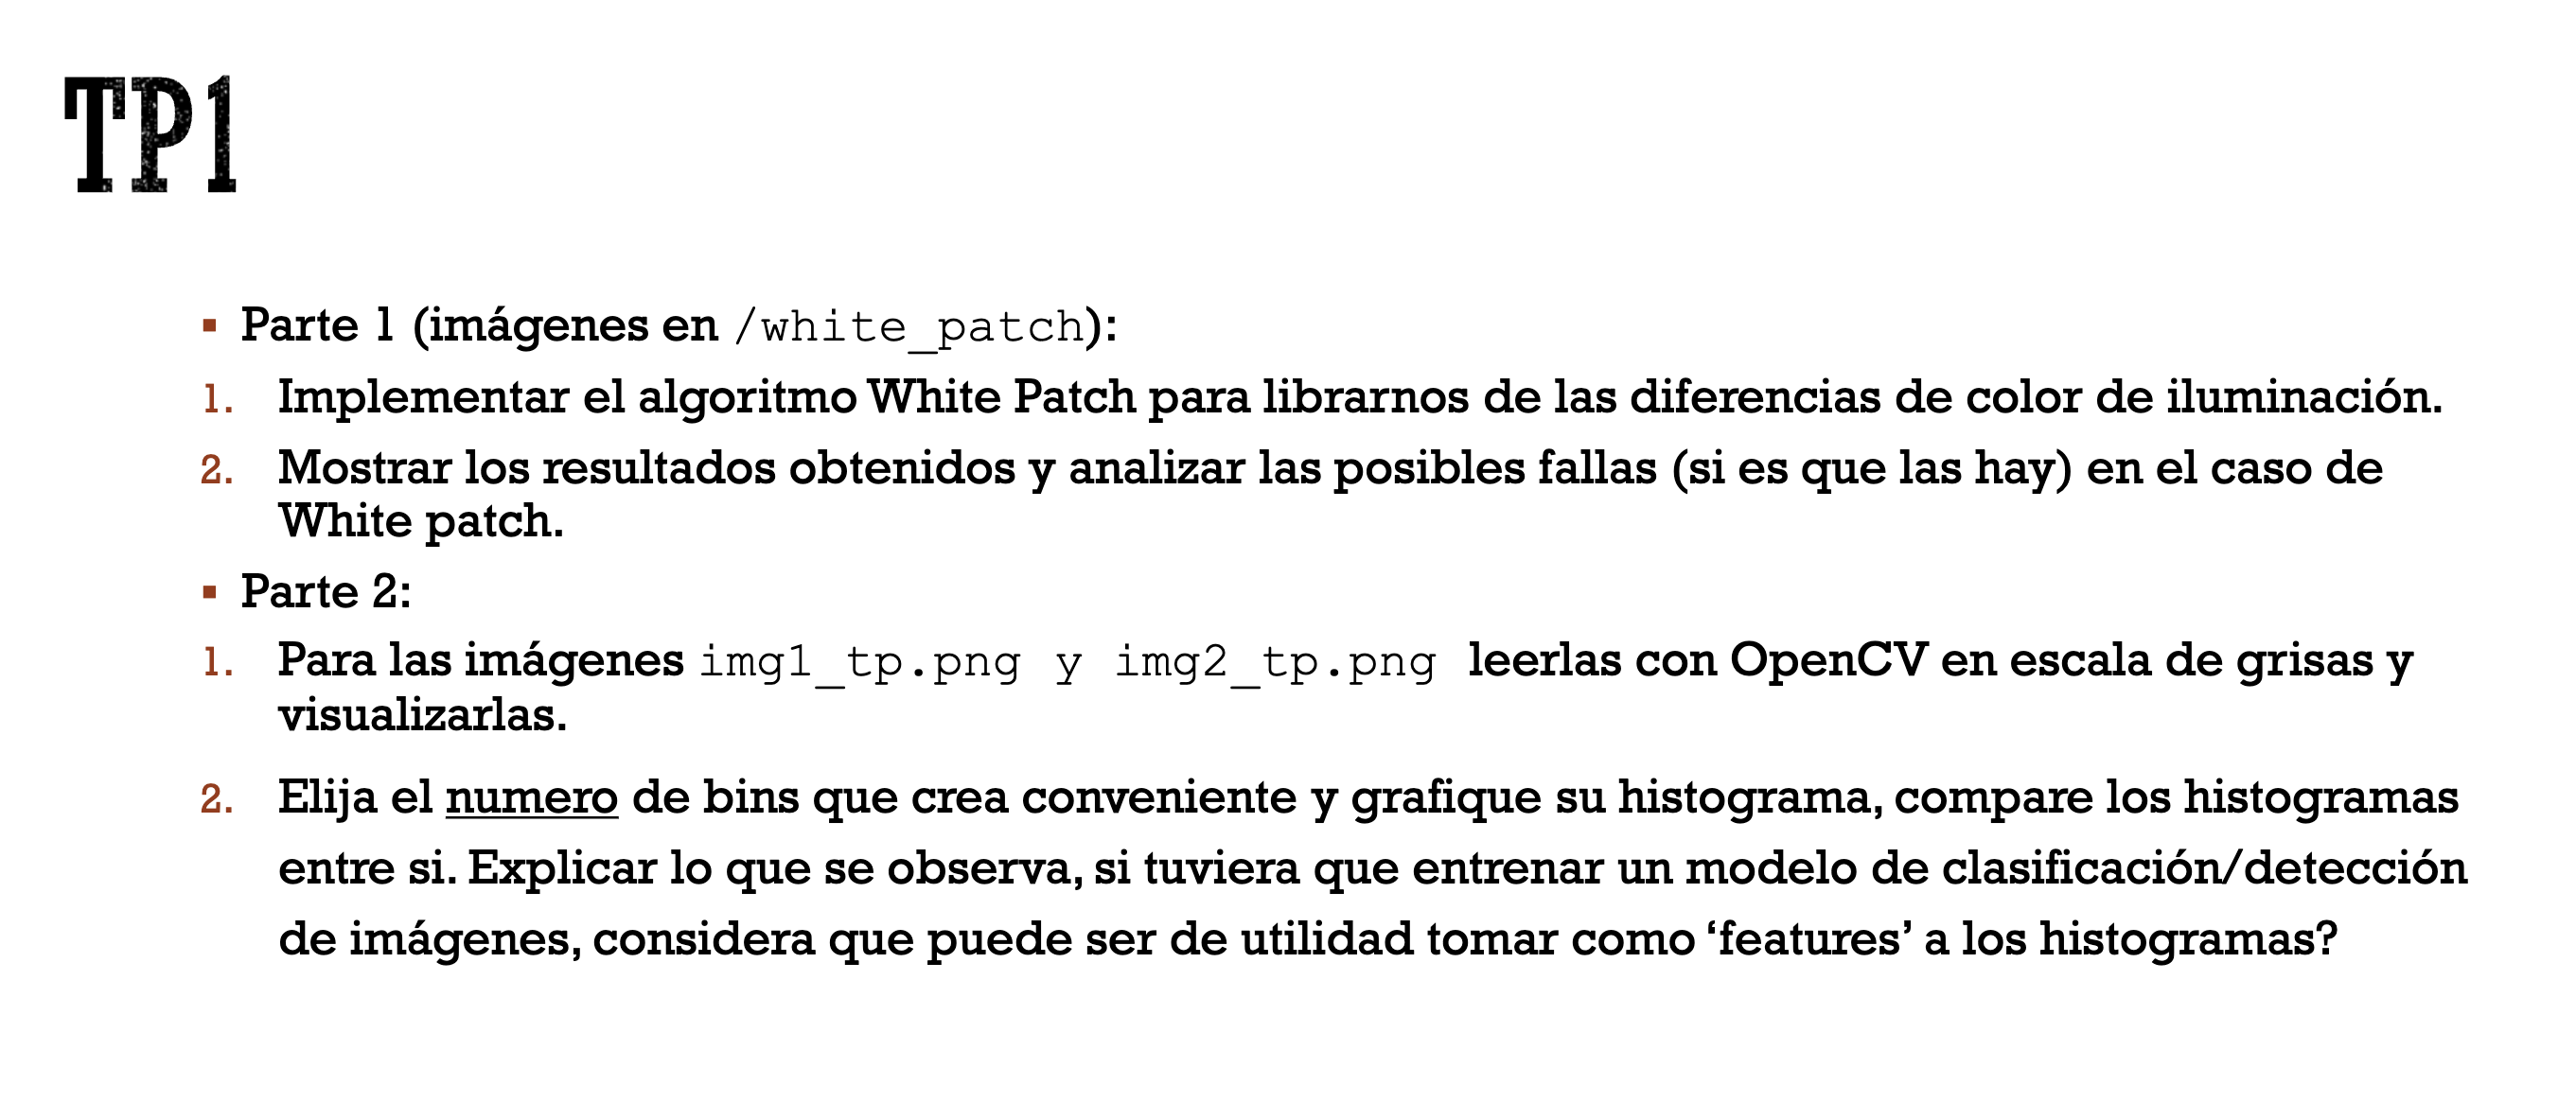


## Parte 1 - Algoritmo White-Patch


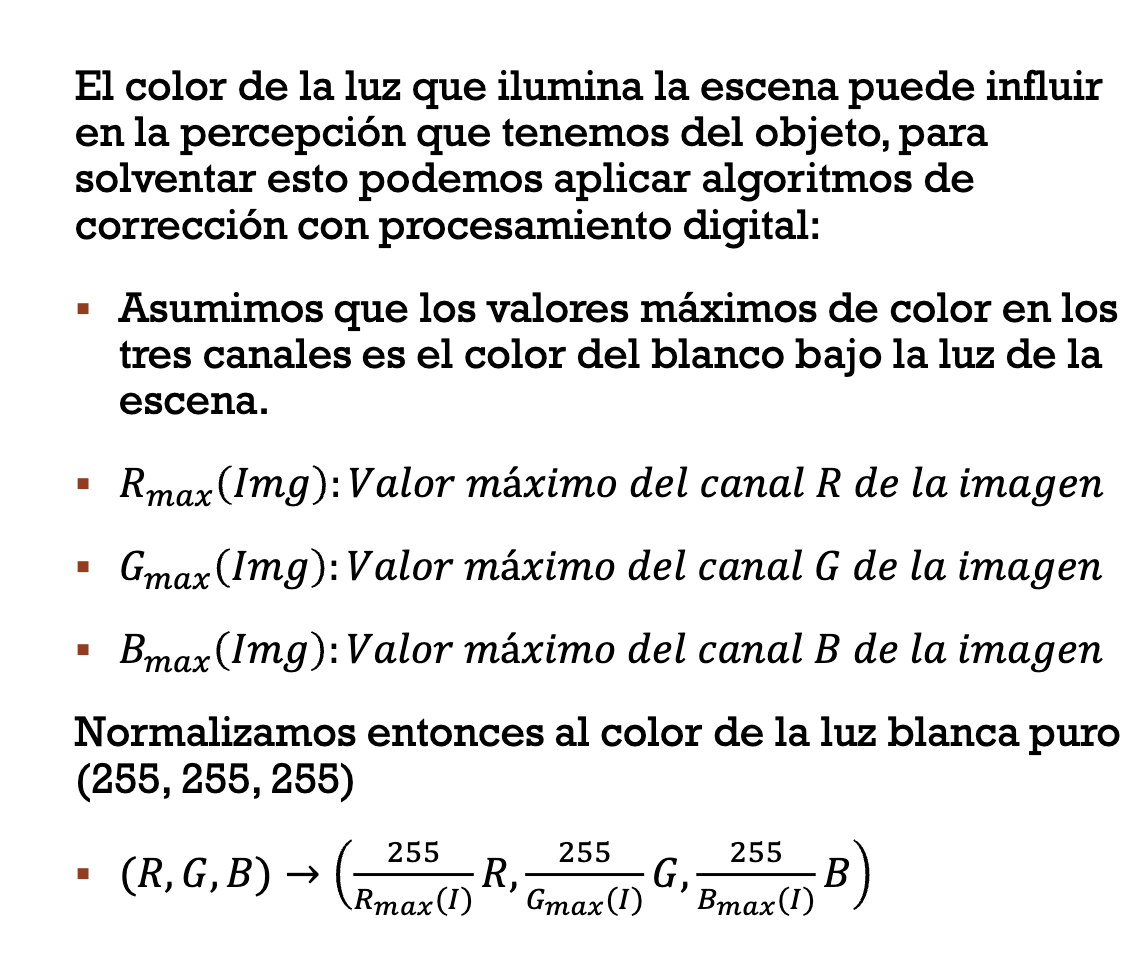


Teoría para tenerla a mano :)


In [2]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

In [ ]:
def white_patch(img_bgr):
    # float32 para no perder los decimales en la division
    img = img_bgr.astype(np.float32)

    for canal in range(3):
        max_val = img[:, :, canal].max()
        if max_val > 0:
            img[:, :, canal] /= max_val

    img = np.clip(img * 255, 0, 255).astype(np.uint8)
    return img

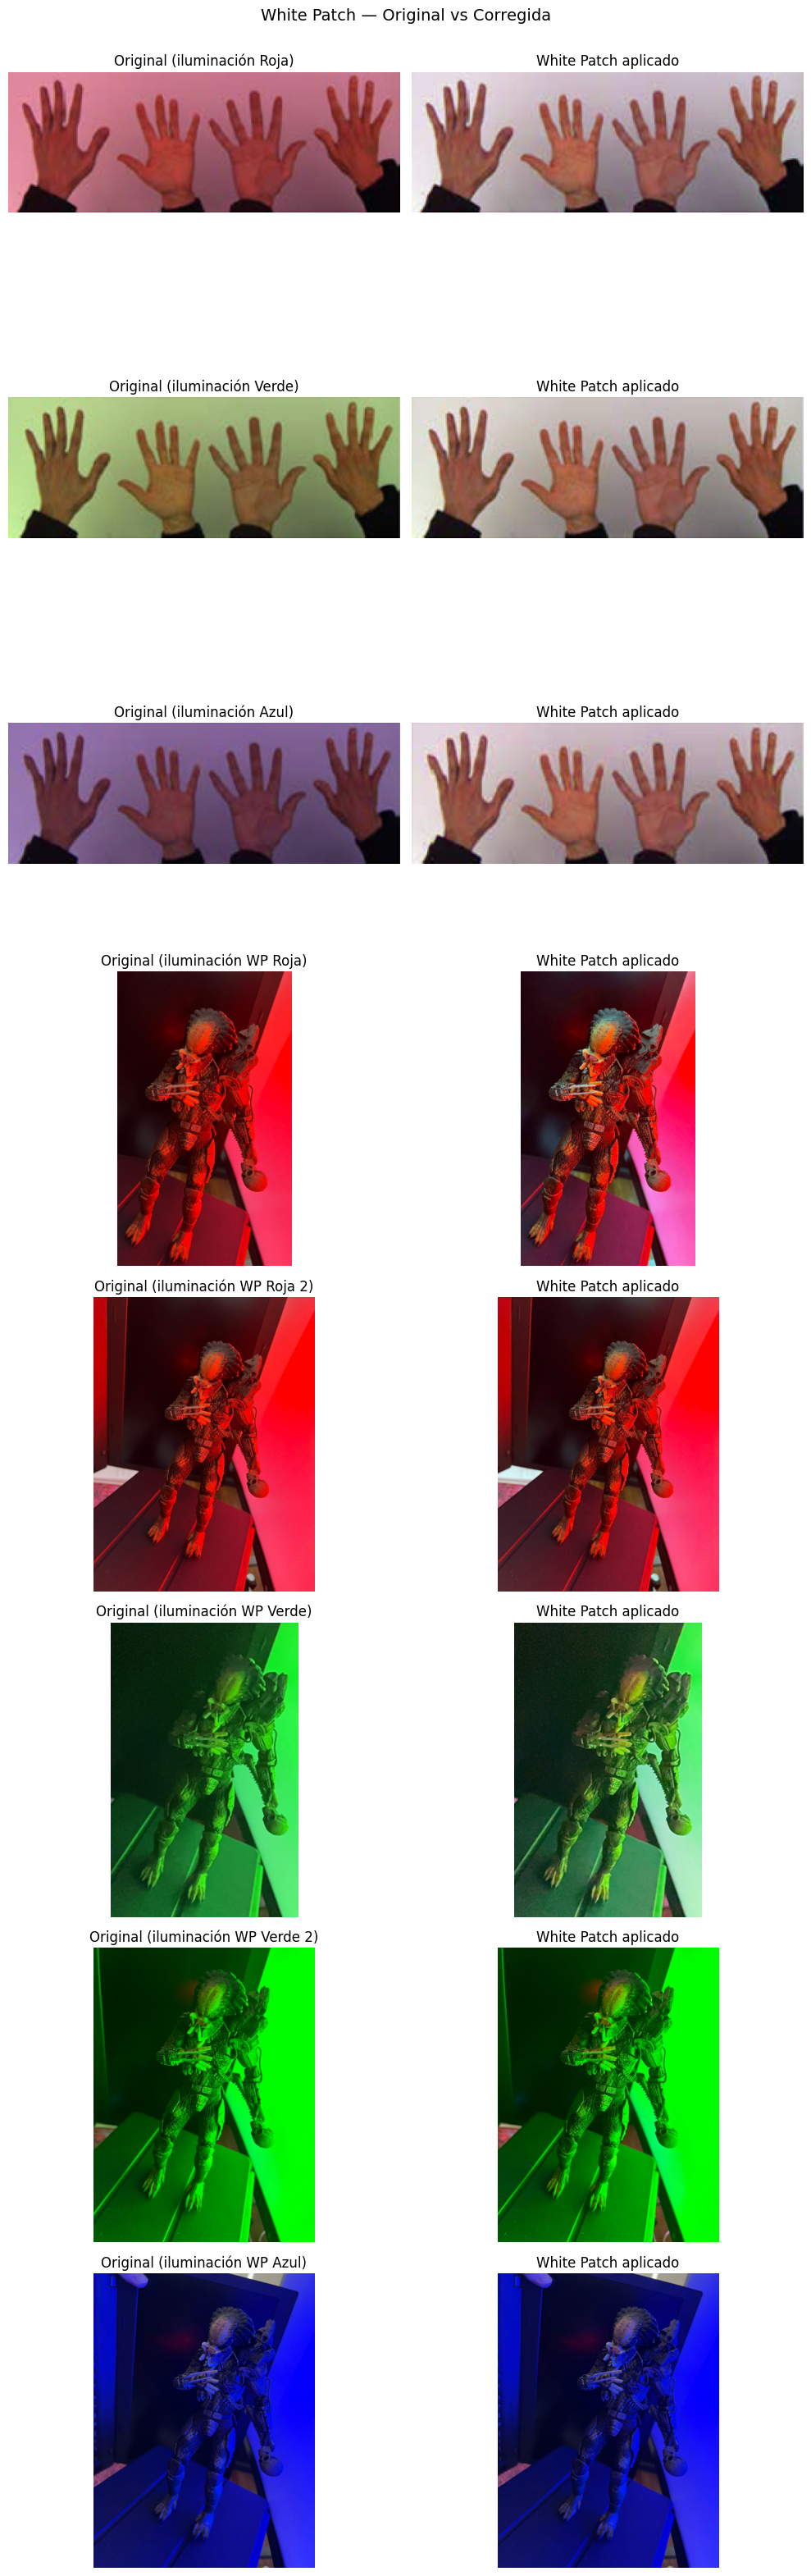

In [ ]:
imagenes = {
    "Roja": "white_patch/test_red.png",
    "Verde": "white_patch/test_green.png",
    "Azul": "white_patch/test_blue.png",
    "WP Roja": "white_patch/wp_red.png",
    "WP Roja 2": "white_patch/wp_red2.jpg",
    "WP Verde": "white_patch/wp_green.png",
    "WP Verde 2": "white_patch/wp_green2.jpg",
    "WP Azul": "white_patch/wp_blue.jpg",
}

fig, axes = plt.subplots(8, 2, figsize=(10, 32))
fig.suptitle("White Patch — Original vs Corregida", fontsize=14)

for fila, (nombre, ruta) in enumerate(imagenes.items()):
    img_bgr = cv.imread(ruta)

    img_corregida_bgr = white_patch(img_bgr)

    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
    img_corr_rgb = cv.cvtColor(img_corregida_bgr, cv.COLOR_BGR2RGB)

    # Columna 0: original
    axes[fila, 0].imshow(img_rgb)
    axes[fila, 0].set_title(f"Original (iluminación {nombre})")
    axes[fila, 0].axis("off")

    # Columna 1: corregida
    axes[fila, 1].imshow(img_corr_rgb)
    axes[fila, 1].set_title(f"White Patch aplicado")
    axes[fila, 1].axis("off")

plt.tight_layout()
plt.show()

Viendo estos resultados podemos ver una falla en las imagenes del predator. En las imagenes de las manos la iluminación tiene tintes moderados, no hay saturación excesiva de algún canal, los tres canales tienen información razonable. Al aplicar el algoritmo white-patch la normalización reequilibra los tres canales y recupera los colores naturales.

En las imagenes del predator podemos ver muy pocas diferencias. En estas imagenes se tiene una saturación excesiva de un solo canal.

Por ejemplo en la imagen del predator roja podriamos decir que el canal R tiene valores muy altos (200-255) en toda la imagen, mientras que G y B tienen valores muy bajos. Al normalizar, el canal R apenas varía, pero G y B se dividen por un máximo muy pequeño y se amplifican bastante, en otras palabras se amplifica ruido. Es por ello, que se ven ligeras diferencias en el cuerpo del predator. Como el algoritmo asume que el pixel más brillante de cada canal es blanco bajo iluminación neutra, esta asunción falla porque el máximo no representa la iluminación sino el color real del objeto.


# Parte 2 - Histogramas


## Visualización en escala de grises


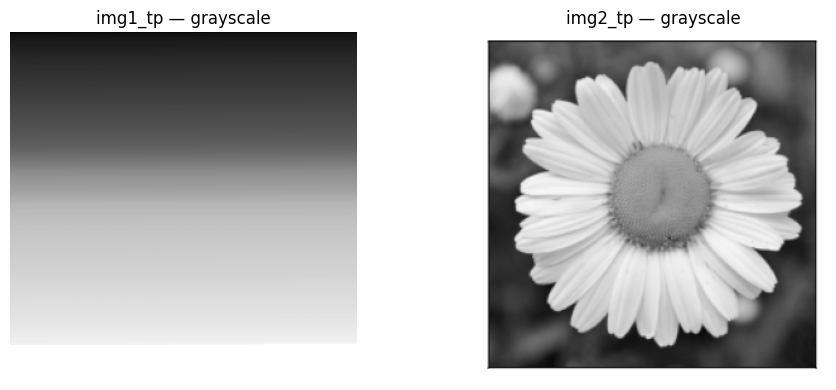

In [ ]:
img1 = cv.imread("img1_tp.png", cv.IMREAD_GRAYSCALE)
img2 = cv.imread("img2_tp.png", cv.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(img1, cmap="gray")
axes[0].set_title("img1_tp — grayscale")
axes[0].axis("off")

axes[1].imshow(img2, cmap="gray")
axes[1].set_title("img2_tp — grayscale")
axes[1].axis("off")

plt.tight_layout()
plt.show()

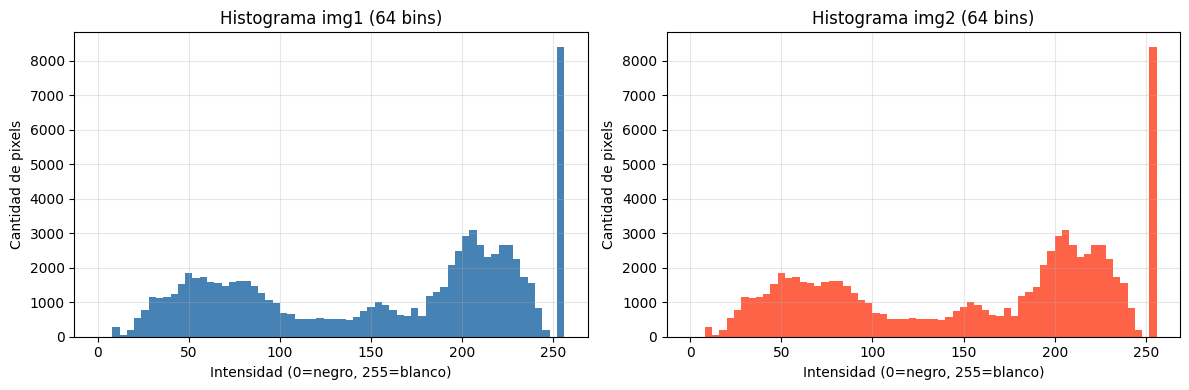

In [14]:
NUM_BINS = 64

hist1 = cv.calcHist([img1], [0], None, [NUM_BINS], [0, 256])
hist2 = cv.calcHist([img2], [0], None, [NUM_BINS], [0, 256])

bin_edges = np.linspace(0, 256, NUM_BINS + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(bin_centers, hist1.ravel(), width=4, color="steelblue")
axes[0].set_title(f"Histograma img1 ({NUM_BINS} bins)")
axes[0].set_xlabel("Intensidad (0=negro, 255=blanco)")
axes[0].set_ylabel("Cantidad de pixels")
axes[0].grid(alpha=0.3)

axes[1].bar(bin_centers, hist2.ravel(), width=4, color="tomato")
axes[1].set_title(f"Histograma img2 ({NUM_BINS} bins)")
axes[1].set_xlabel("Intensidad (0=negro, 255=blanco)")
axes[1].set_ylabel("Cantidad de pixels")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Eligo 64 bins ya que es donde mas se puede ver claramente la distribución, más balanceado que usar 256 o algún valor mayor o menor que 64.

Aqui se ve algo interesante, y es que los dos histogramas son idénticos. Un histograma es simplemente un contador de pixeles por nivel de intensidad. En este caso de 64 bins nos dice cuantos pixeles tienen intensidad entre 4 y 7 por ejemplo. No dice nada sobre donde están esos pixeles. Estas dos imagenes tienen la misma cantidad de pixeles de cada brillo, a pesar de que sean imagenes completamente diferentes.


### Los histogramos se pueden usar como feature para un modelo de clasificación/detección de imágenes?

Tienen algunas ventajas:

- Son invariantes a traslación y rotación, ya que cuenta cantidad de pixeles.
- Rápidos de calcular
- Capturan iluminación global ya que cuenta la cantidad de pixeles y su intensidad

Desventajas:

- Por lo visto anteriormente, no puede distinguir de imagenes diferentes aunque el histograma sea igual.
- El histograma no captura forma, estructuras, espacio, etc, basicamente todo lo que hace que una imagen sea reconocible.

Son útiles como features complementarios y cuando el problema cuenta con clases con distribuciones de intensidad claramente distintas. Para detección o clasificación de objetos, son insuficientes.
